# Predicting House Prices with Linear Regression

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/sample_data/Housing.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 2. Data Exploration and Cleaning

In [2]:
# Display the shape of the DataFrame
print(f"DataFrame shape: {df.shape}")

# Display data types of each column
print("\nData types:")
print(df.info())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

DataFrame shape: (545, 13)

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

Missing values:
price               0
area                0
bedrooms            0
bathrooms           0
stor

## Data Preprocessing: Handling Categorical Variables and Feature Scaling

In [3]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first 5 rows of the encoded DataFrame to show the changes
display(df_encoded.head())

# Display the shape of the new DataFrame to see the increase in columns
print(f"\nShape of DataFrame after one-hot encoding: {df_encoded.shape}")

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False



Shape of DataFrame after one-hot encoding: (545, 14)


## 3. Feature Selection, Data Splitting, and Scaling

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target variable (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the training features
X_train_scaled = scaler.fit_transform(X_train)

# Apply scaling to the test features using the scaler fitted on the training data
X_test_scaled = scaler.transform(X_test)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train_scaled: (436, 13)
Shape of X_test_scaled: (109, 13)
Shape of y_train: (436,)
Shape of y_test: (109,)


## 4. Model Training

In [5]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the scaled training data
model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 5. Model Evaluation

In [6]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions on the scaled test set
y_pred = model.predict(X_test_scaled)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 1754318687330.67
Root Mean Squared Error (RMSE): 1324506.96
R-squared (R2): 0.65


## 6. Visualization: Predicted vs. Actual Values

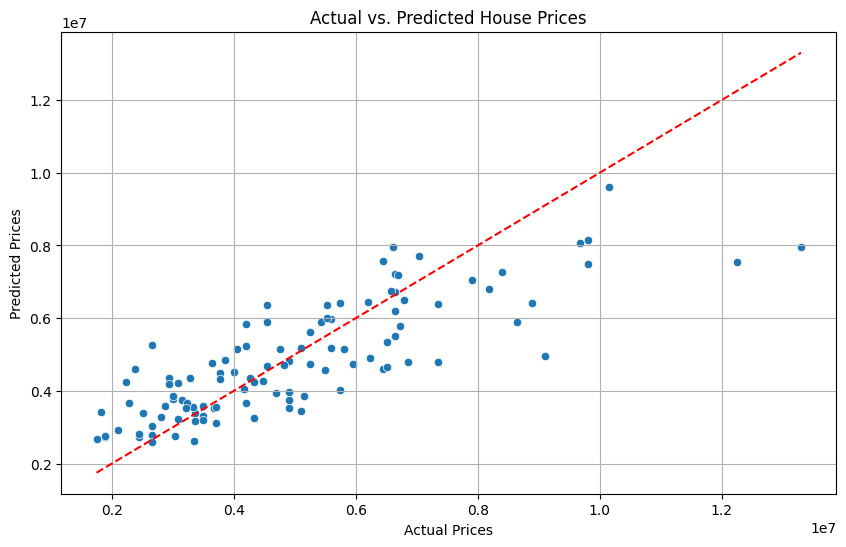

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted House Prices")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # Perfect prediction line
plt.grid(True)
plt.show()

## Resources

### Project Overview
This project aimed to build and evaluate a linear regression model to predict house prices using a given dataset. Linear regression is a fundamental machine learning algorithm used for predicting a numerical outcome based on relevant features. The process involved several key stages from data acquisition to model visualization.

### 1. Data Collection and Initial Loading
- **Objective:** To load the dataset into a usable format for analysis.
- **Action:** The `Housing.csv` dataset was loaded into a pandas DataFrame. Pandas is a powerful library for data manipulation and analysis in Python.
- **Code:** `df = pd.read_csv('/content/sample_data/Housing.csv')`
- **Outcome:** The `df.head()` command displayed the first five rows, giving an initial glimpse into the data structure, including numerical features like `price`, `area`, `bedrooms`, and `bathrooms`, and categorical features such as `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`, and `furnishingstatus`.

### 2. Data Exploration and Cleaning
- **Objective:** To understand the dataset's structure, identify data types, and check for missing values to ensure data quality.
- **Actions:**
    - Checked the DataFrame's shape (`df.shape`) to know the number of rows and columns.
    - Used `df.info()` to get a summary of the DataFrame, including column names, non-null counts, and data types.
    - Checked for missing values in each column using `df.isnull().sum()`.
- **Outcome:**
    - The DataFrame contains 545 rows and 13 columns.
    - It was confirmed that there are no missing values in any of the columns, which simplifies the cleaning process.
    - Several columns were identified as `object` (categorical) type, which would require conversion for machine learning algorithms.

### 3. Data Preprocessing: Handling Categorical Variables and Feature Scaling
- **Objective:** To convert categorical features into a numerical format and scale numerical features to prepare the data for the linear regression model.
- **Actions:**
    - **One-Hot Encoding:** Categorical columns (identified as `object` type) were converted into numerical format using `pd.get_dummies()`. The `drop_first=True` argument was used to avoid multicollinearity (dummy variable trap).
    - **Data Splitting:** The dataset was split into features (X) and the target variable (y - 'price'). Then, `train_test_split` from `sklearn.model_selection` was used to divide the data into training (80%) and testing (20%) sets, ensuring the model's performance could be evaluated on unseen data.
    - **Feature Scaling:** `StandardScaler` from `sklearn.preprocessing` was applied to the numerical features in both training and testing sets. Scaling ensures that features with larger values do not dominate the learning process and helps the model converge faster.
- **Code:** `df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)`,
`X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)`,
`X_train_scaled = scaler.fit_transform(X_train)`, `X_test_scaled = scaler.transform(X_test)`
- **Outcome:** The data is now in a fully numerical and scaled format, ready for model training. The number of columns increased due to one-hot encoding.

### 4. Model Training
- **Objective:** To train a linear regression model using the preprocessed training data.
- **Action:** A `LinearRegression` model from `sklearn.linear_model` was initialized and then trained using the scaled training features (`X_train_scaled`) and the corresponding training target variable (`y_train`).
- **Code:** `model = LinearRegression()`,
`model.fit(X_train_scaled, y_train)`
- **Outcome:** The linear regression model was successfully trained, learning the relationships between the features and the house prices.

### 5. Model Evaluation
- **Objective:** To assess the performance of the trained model on the unseen test data.
- **Actions:**
    - The trained model made predictions on the scaled test features (`X_test_scaled`).
    - Key regression metrics were calculated:
        - **Mean Squared Error (MSE):** The average of the squared differences between predicted and actual values. A lower MSE indicates better performance.
        - **Root Mean Squared Error (RMSE):** The square root of MSE, providing an error metric in the same units as the target variable, making it more interpretable.
        - **R-squared (R2):** Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. R-squared values range from 0 to 1, with higher values indicating a better fit.
- **Code:** `y_pred = model.predict(X_test_scaled)`,
`mse = mean_squared_error(y_test, y_pred)`,
`rmse = np.sqrt(mse)`,
`r2 = r2_score(y_test, y_pred)`
- **Outcome:**
    - **MSE:** 1,754,318,687,330.67
    - **RMSE:** 1,324,506.96
    - **R2:** 0.65
    - An R-squared value of 0.65 suggests that approximately 65% of the variance in house prices can be explained by the model's features, which is a reasonably good fit.

### 6. Visualization: Predicted vs. Actual Values
- **Objective:** To visually compare the model's predictions with the actual house prices to understand the model's performance and identify any patterns or discrepancies.
- **Action:** A scatter plot was created using `matplotlib` and `seaborn`, plotting the actual `y_test` values against the predicted `y_pred` values. A red dashed line representing perfect predictions (`y = x`) was added for reference.
- **Code:** `sns.scatterplot(x=y_test, y=y_pred)`,
`plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')`
- **Outcome:** The scatter plot showed a positive correlation between actual and predicted prices. While the points clustered around the perfect prediction line, there was some spread, particularly for higher prices, indicating areas where the model could be improved. Overall, the visualization confirmed that the model captures the general trend of house prices.